# Lab 11 — LLM extraction as engineering (schema-first)

Pipeline:
- schema-first JSON design
- raw extraction
- strict JSON/schema validation
- bounded repair loop
- metrics before/after repair
- 15 problematic examples

In [1]:
%pip install -q openai jsonschema pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations
import json, os, sys
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
project_root = Path.cwd()
if not (project_root / "project_lab11").exists():
    for p in [project_root, *project_root.parents]:
        if (p / "project_lab11").exists():
            project_root = p
            break
lab_root = project_root / "project_lab11"
src_root = lab_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
from json_schema import EXTRACTION_TASK, get_extraction_schema, schema_as_markdown
from llm_extract import ExtractConfig, LLMExtractionClient
from repair_loop import run_repair_loop
from validator import validate_output
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

## 1. Data access

In [3]:
full_data_candidates = [lab_root / "data" / "processed_v2" / "processed_v2.csv", project_root / "project_lab2" / "data" / "processed_v2" / "processed_v2.csv"]
full_data_path = next((p for p in full_data_candidates if p.exists()), None)
if full_data_path is None:
    raise FileNotFoundError("processed_v2.csv not found")
eval_df = pd.read_json(lab_root / "data" / "sample" / "eval_set_lab11.jsonl", lines=True)
full_df = pd.read_csv(full_data_path)
print("full_data_path =", full_data_path)
print("full_rows =", len(full_df))
print("evaluation_rows =", len(eval_df))
print("text_field = text")
eval_df[["text_id", "label"]].head()

full_data_path = C:\Users\maia1\data\politiekh\masters\nlp\project_lab2\data\processed_v2\processed_v2.csv
full_rows = 1000
evaluation_rows = 20
text_field = text


,text_id,label
0,10001201,Question / Request for Help
1,8664,Gratitude / Positive Feedback
2,10000591,Question / Request for Help
3,6771,Suggestion / Idea
4,10005935,Question / Request for Help


## 2. Extraction task definition

In [4]:
print(EXTRACTION_TASK)
print("\nEvaluation set = curated service/admin messages with realistic structured fields.")


Extract structured support/admin-service attributes from a Ukrainian user message. The pipeline is designed for state-service and compensation-related texts.

Evaluation set = curated service/admin messages with realistic structured fields.


## 3. JSON schema design

In [5]:
schema = get_extraction_schema()
print(schema_as_markdown())

# Lab 11 extraction schema

Task: Extract structured support/admin-service attributes from a Ukrainian user message. The pipeline is designed for state-service and compensation-related texts.

## Fields
- `primary_service`: {"type": "string", "enum": ["єВідновлення", "Дія", "ЦНАП", "Паспортний сервіс", "Нотаріус", "Державний реєстр нерухомості", "Інша держпослуга", "unknown"]}
- `services_mentioned`: {"type": "array", "items": {"type": "string", "enum": ["єВідновлення", "Дія", "ЦНАП", "Паспортний сервіс", "Нотаріус", "Державний реєстр нерухомості", "Інша держпослуга", "unknown"]}, "uniqueItems": true}
- `issue_type`: {"type": "string", "enum": ["compensation_status", "application_submission", "document_requirement", "payment_or_amount", "registration_or_queue", "service_access_problem", "inheritance_or_notary", "consultation_or_advice", "other"]}
- `document_type`: {"type": ["string", "null"]}
- `amounts_uah`: {"type": "array", "items": {"type": "number", "minimum": 0}}
- `date_text`: 

## 4. Evaluation set

In [6]:
eval_df[["text_id", "label", "text"]].head(10)

,text_id,label,text
0,10001201,Question / Request for Help,"Цифрова держава Повідомлення 123 від 18.04.2023 року надіслано Згодом буде створено спеціальну комісію, яка оцінить збитки. Ми сповістимо вас про наступні к..."
1,8664,Gratitude / Positive Feedback,"На пл. Ринок ЦНАП м.Львова, швидке ьа якісне вирішення питань"
2,10000591,Question / Request for Help,"Доброго дня. При створенні заяви в Дії на пошкоджене майно (ЄВідновлення) потрібна згода другого власника квартири, мого сина. Він проживає зі мною. Він дор..."
3,6771,Suggestion / Idea,"За умови карантину рекомендую завжди дзвонити в установу куди прямуєте, а потім за результатами отриманої інформації йдете підготовлені. Я так не зробила, в..."
4,10005935,Question / Request for Help,У Витягу про місце проживання невірно вказано номер будинку. Як це можливо виправити?
5,10000504,Question / Request for Help,"Скажіть, будь ласка,за знищене 100% майно ще не виплачують кошти? Дякую."
6,17010,Complaint / Dissatisfaction,"Зверталася двічі щодо реєстрації прав власності . Попередньо приходила на консультацію. Спеціаліст на робочому місці 23 подивилася, сказала все ок. Ми приве..."
7,10000628,Suggestion / Idea,"Доброго дня, спробуйте при створенні замовлення обрати оплата картою і зробіть оплату з карти єВідновлення."
8,3167,Neutral Comment,"У черзі реєструвалася з вечора онлайн, прийшла заздалегідь, оскільки потрібно було сплатити штраф за прострочення подачі документів (фотографія на 25), вияв..."
9,10005890,Question / Request for Help,Як отримати кошти на відновлення будинку або квартири програмою Євідновлення


## 5. Baseline prompt

In [7]:
config = ExtractConfig(provider=os.getenv("LAB11_PROVIDER", "auto"), model=os.getenv("OPENAI_MODEL", "gpt-4.1-mini"))
client = LLMExtractionClient(config)
print("initial_provider =", client.active_provider)
print(client.build_baseline_prompt(eval_df.iloc[0]["text"]))

initial_provider = openai
Extract the support/admin attributes from the Ukrainian message below. Return only one JSON object with exactly these fields: primary_service, services_mentioned, issue_type, document_type, amounts_uah, date_text, location_text. Use null for missing string values and [] for missing amounts. Allowed primary_service values: ['єВідновлення', 'Дія', 'ЦНАП', 'Паспортний сервіс', 'Нотаріус', 'Державний реєстр нерухомості', 'Інша держпослуга', 'unknown']. Allowed issue_type values: ['compensation_status', 'application_submission', 'document_requirement', 'payment_or_amount', 'registration_or_queue', 'service_access_problem', 'inheritance_or_notary', 'consultation_or_advice', 'other']. Do not add commentary.

Text:
Цифрова держава Повідомлення 123 від 18.04.2023 року надіслано Згодом буде створено спеціальну комісію, яка оцінить збитки. Ми сповістимо вас про наступні кроки, коли буде визначено порядок та розпочато процес компенсації Разом до перемоги! Слава Україні! А

## 6. Raw extraction

In [8]:
raw_rows = []
for row in eval_df.itertuples(index=False):
    raw = client.extract(row.text)
    vr = validate_output(raw, schema)
    raw_rows.append({"text_id": row.text_id, "label": row.label, "text": row.text, "expected": row.expected, "raw_output": raw, "raw_parse_ok": vr.parse_ok, "raw_schema_ok": vr.schema_ok, "raw_error_type": vr.error_type, "raw_error_message": vr.error_message, "raw_parsed": vr.parsed})
raw_df = pd.DataFrame(raw_rows)
print("provider_after_raw =", client.active_provider)
if client.last_provider_error:
    print("provider_fallback_reason =", client.last_provider_error)
raw_df[["text_id", "raw_parse_ok", "raw_schema_ok", "raw_error_type"]].head(10)

provider_after_raw = mock
provider_fallback_reason = Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


,text_id,raw_parse_ok,raw_schema_ok,raw_error_type
0,10001201,True,True,NaN
1,8664,True,False,missing_required_field
2,10000591,True,True,NaN
3,6771,True,False,missing_required_field
4,10005935,False,False,json_parse_error
5,10000504,False,False,json_parse_error
6,17010,True,False,wrong_field_type
7,10000628,False,False,json_parse_error
8,3167,True,True,NaN
9,10005890,False,False,json_parse_error


## 7. JSON validator

In [9]:
raw_parse_rate = float(raw_df["raw_parse_ok"].mean())
raw_schema_rate = float(raw_df["raw_schema_ok"].mean())
print("raw_parse_success_rate =", round(raw_parse_rate, 3))
print("raw_schema_valid_rate =", round(raw_schema_rate, 3))
raw_df["raw_error_type"].fillna("ok").value_counts()

raw_parse_success_rate = 0.5
raw_schema_valid_rate = 0.3


raw_error_type
json_parse_error          10
ok                         6
missing_required_field     2
wrong_field_type           2
Name: count, dtype: int64

## 8. Repair loop

In [10]:
repair_rows = []
for row in eval_df.itertuples(index=False):
    rec = run_repair_loop(int(row.text_id), row.text, client, schema, max_repairs=2)
    repair_rows.append({"text_id": rec.text_id, "raw_output": rec.raw_output, "raw_parse_ok": rec.raw_validation.parse_ok, "raw_schema_ok": rec.raw_validation.schema_ok, "raw_error_type": rec.raw_validation.error_type, "raw_error_message": rec.raw_validation.error_message, "final_output": rec.final_output, "final_parse_ok": rec.final_validation.parse_ok, "final_schema_ok": rec.final_validation.schema_ok, "final_error_type": rec.final_validation.error_type, "final_error_message": rec.final_validation.error_message, "final_parsed": rec.final_validation.parsed, "repairs_used": rec.repairs_used, "repair_needed": rec.repair_needed})
repair_df = pd.DataFrame(repair_rows)
results_df = eval_df.merge(repair_df, on="text_id", how="left")
results_df[["text_id", "raw_schema_ok", "final_schema_ok", "repairs_used"]].head(10)


,text_id,raw_schema_ok,final_schema_ok,repairs_used
0,10001201,True,True,0
1,8664,False,True,1
2,10000591,True,True,0
3,6771,False,True,1
4,10005935,False,True,1
5,10000504,False,True,1
6,17010,False,True,1
7,10000628,False,True,1
8,3167,True,True,0
9,10005890,False,True,1


## 9. Metrics: valid JSON rate

In [11]:
def canonical(value):
    return sorted(value) if isinstance(value, list) else value

def assess_semantics(expected_obj, predicted_obj):
    if not isinstance(predicted_obj, dict):
        return {"field_matches": 0, "field_total": 0, "issues": ["not_json_at_all"]}
    matches, total, issues = 0, 0, []
    for key, expected_value in expected_obj.items():
        predicted_value = predicted_obj.get(key)
        total += 1
        if canonical(predicted_value) == canonical(expected_value):
            matches += 1
        elif expected_value in (None, []) and predicted_value not in (None, [], ""):
            issues.append("hallucinated_field/value")
        elif key == "document_type" and expected_value and predicted_value:
            issues.append("normalization_issue")
        else:
            issues.append("semantic_extraction_error")
    return {"field_matches": matches, "field_total": total, "issues": issues}

semantic_rows = []
for row in results_df.itertuples(index=False):
    a = assess_semantics(row.expected, row.final_parsed)
    semantic_rows.append({"text_id": row.text_id, "field_matches": a["field_matches"], "field_total": a["field_total"], "semantic_issues": a["issues"]})
semantic_df = pd.DataFrame(semantic_rows)
results_df = results_df.merge(semantic_df, on="text_id", how="left")
metrics = {
    "raw_valid_json_rate": float(results_df["raw_parse_ok"].mean()),
    "raw_schema_valid_rate": float(results_df["raw_schema_ok"].mean()),
    "post_repair_valid_json_rate": float(results_df["final_parse_ok"].mean()),
    "schema_valid_json_rate": float(results_df["final_schema_ok"].mean()),
    "average_repairs_per_example": float(results_df["repairs_used"].mean()),
    "repair_needed_rate": float(results_df["repair_needed"].mean()),
    "repair_failed_rate": float((~results_df["final_schema_ok"]).mean()),
    "mean_field_match_rate": float((results_df["field_matches"] / results_df["field_total"]).mean()),
}
metrics

{'raw_valid_json_rate': 0.5,
 'raw_schema_valid_rate': 0.3,
 'post_repair_valid_json_rate': 1.0,
 'schema_valid_json_rate': 1.0,
 'average_repairs_per_example': 0.7,
 'repair_needed_rate': 0.7,
 'repair_failed_rate': 0.0,
 'mean_field_match_rate': 0.8571428571428571}

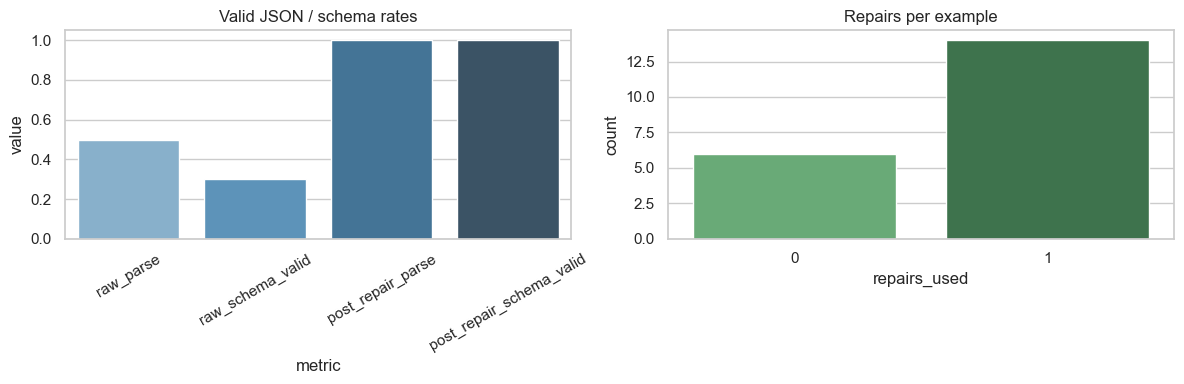

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rate_df = pd.DataFrame({"metric": ["raw_parse", "raw_schema_valid", "post_repair_parse", "post_repair_schema_valid"], "value": [metrics["raw_valid_json_rate"], metrics["raw_schema_valid_rate"], metrics["post_repair_valid_json_rate"], metrics["schema_valid_json_rate"]]})
sns.barplot(data=rate_df, x="metric", y="value", hue="metric", legend=False, palette="Blues_d", ax=axes[0])
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Valid JSON / schema rates")
repair_hist = results_df["repairs_used"].value_counts().sort_index().rename_axis("repairs_used").reset_index(name="count")
sns.barplot(data=repair_hist, x="repairs_used", y="count", hue="repairs_used", legend=False, palette="Greens_d", ax=axes[1])
axes[1].set_title("Repairs per example")
plt.tight_layout()
plt.show()

## 10. Error analysis

In [13]:
def classify_problem(row):
    cats = []
    if not row.raw_parse_ok:
        cats.append("json_parse_error")
    if row.raw_parse_ok and not row.raw_schema_ok:
        cats.append(row.raw_error_type or "schema_violation")
    if row.final_schema_ok:
        cats.extend(row.semantic_issues)
    return cats or ["ok"]

results_df["problem_categories"] = results_df.apply(classify_problem, axis=1)
problem_counter = Counter(cat for cats in results_df["problem_categories"] for cat in cats if cat != "ok")
problem_counter

Counter({'semantic_extraction_error': 19,
         'json_parse_error': 10,
         'missing_required_field': 2,
         'wrong_field_type': 2,
         'normalization_issue': 1})

In [14]:
problem_examples = results_df.copy()
problem_examples["problem_score"] = ((~problem_examples["raw_parse_ok"]).astype(int) * 3 + (~problem_examples["raw_schema_ok"]).astype(int) * 2 + (problem_examples["field_total"] - problem_examples["field_matches"]))
problem_examples = problem_examples.sort_values(["problem_score", "repairs_used"], ascending=False).head(15)
problem_examples[["text_id", "raw_error_type", "final_schema_ok", "repairs_used", "problem_categories"]]

,text_id,raw_error_type,final_schema_ok,repairs_used,problem_categories
4,10005935,json_parse_error,True,1,"[json_parse_error, semantic_extraction_error, semantic_extraction_error]"
14,8584,json_parse_error,True,1,"[json_parse_error, semantic_extraction_error, normalization_issue]"
5,10000504,json_parse_error,True,1,"[json_parse_error, semantic_extraction_error]"
9,10005890,json_parse_error,True,1,"[json_parse_error, semantic_extraction_error]"
15,10003613,json_parse_error,True,1,"[json_parse_error, semantic_extraction_error]"
7,10000628,json_parse_error,True,1,[json_parse_error]
10,10002040,json_parse_error,True,1,[json_parse_error]
11,10005853,json_parse_error,True,1,[json_parse_error]
12,10002762,json_parse_error,True,1,[json_parse_error]
13,4604,json_parse_error,True,1,[json_parse_error]


In [15]:
for row in problem_examples.itertuples(index=False):
    print("=" * 120)
    print(f"text_id={row.text_id}")
    print("TEXT:", row.text)
    print("EXPECTED:", json.dumps(row.expected, ensure_ascii=False))
    print("RAW_VALID:", row.raw_parse_ok, row.raw_schema_ok, row.raw_error_type, row.raw_error_message)
    print("FINAL_VALID:", row.final_parse_ok, row.final_schema_ok, row.final_error_type, row.final_error_message)
    print("FINAL_PRED:", json.dumps(row.final_parsed, ensure_ascii=False))
    print("PROBLEM_CATEGORIES:", row.problem_categories)

text_id=10005935
TEXT: У Витягу про місце проживання невірно вказано номер будинку. Як це можливо виправити?
EXPECTED: {"primary_service": "Інша держпослуга", "services_mentioned": ["Інша держпослуга"], "issue_type": "service_access_problem", "document_type": "витяг про місце проживання", "amounts_uah": [], "date_text": null, "location_text": null}
RAW_VALID: False False json_parse_error Expecting value: line 1 column 1 (char 0)
FINAL_VALID: True True None None
FINAL_PRED: {"primary_service": "Інша держпослуга", "services_mentioned": ["Інша держпослуга"], "issue_type": "other", "document_type": null, "amounts_uah": [], "date_text": null, "location_text": null}
PROBLEM_CATEGORIES: ['json_parse_error', 'semantic_extraction_error', 'semantic_extraction_error']
text_id=8584
TEXT: Для заміни паспорта скористався послугою зміни реєстрації в ЦНАПі на Костя Левицького. Але в переліку документів які потрібні для отримання нового паспорту є довідка з…
EXPECTED: {"primary_service": "Паспортний се

## 11. Generate docs/audit_summary_lab11.md

In [16]:
def fmt(v):
    return f"{v:.3f}"
field_break_counter = Counter()
for row in results_df.itertuples(index=False):
    if isinstance(row.final_parsed, dict):
        for key, expected_value in row.expected.items():
            if canonical(row.final_parsed.get(key)) != canonical(expected_value):
                field_break_counter[key] += 1
summary_lines = [
    "# Lab 11 audit summary", "",
    f"- Extraction case: support/admin message -> structured service JSON ({len(schema['properties'])} fields)",
    f"- Evaluation set size: {len(results_df)}",
    f"- Raw valid JSON rate: {fmt(metrics['raw_valid_json_rate'])}",
    f"- Raw schema-valid JSON rate: {fmt(metrics['raw_schema_valid_rate'])}",
    f"- Post-repair valid JSON rate: {fmt(metrics['post_repair_valid_json_rate'])}",
    f"- Schema-valid JSON rate: {fmt(metrics['schema_valid_json_rate'])}",
    f"- Average repairs per example: {fmt(metrics['average_repairs_per_example'])}",
    f"- Repair needed rate: {fmt(metrics['repair_needed_rate'])}",
    f"- Repair failed rate: {fmt(metrics['repair_failed_rate'])}",
    "- Most fragile fields: " + ", ".join(f"`{n}`={c}" for n, c in field_break_counter.most_common(4)),
    "- Most frequent error categories: " + ", ".join(f"`{n}`={c}" for n, c in problem_counter.most_common(5)),
    "- Schema-first result: validator + repair loop materially improved structured-output reliability; semantic mistakes still remain on ambiguous fields.",
    "", f"- Provider used during this run: `{client.active_provider}`",
]
(lab_root / "docs" / "audit_summary_lab11.md").write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
schema_lines = [
    "# Lab 11 extraction schema", "",
    "- Extraction task: support/admin message -> structured state-service attributes",
    "- Fields: `primary_service`, `services_mentioned`, `issue_type`, `document_type`, `amounts_uah`, `date_text`, `location_text`",
    "- Required fields: all seven fields are required by schema; nullable fields use `null`, and `amounts_uah` uses `[]` when absent.", "",
    "## JSON schema", "```json", json.dumps(schema, ensure_ascii=False, indent=2), "```", "",
    "## Null / missing rules",
    "- `document_type`, `date_text`, `location_text`: use `null` if the value is not explicit in the text.",
    "- `amounts_uah`: use an empty array if no money amount is explicitly stated.", "",
    "## Frequent problem fields", "- " + ", ".join(f"`{n}`={c}" for n, c in field_break_counter.most_common(4)), "",
    "## What repair loop actually fixes",
    "- Broken wrappers such as markdown fences / extra commentary around JSON.",
    "- Missing required fields and wrong field types from the raw extraction output.",
    "- It does not fully solve semantic ambiguity in service choice or normalized document naming.",
]
(lab_root / "docs" / "extraction_schema_lab11.md").write_text("\n".join(schema_lines) + "\n", encoding="utf-8")
dataset_card = "\n".join([
    "# Dataset card", "",
    "- Source corpus: cleaned `processed_v2` texts from Lab 2.",
    "- Lab 11 structured extraction case: support/admin-service messages about compensation, documents, queues, and state-service access.",
    "- Text field used in this repo: `text` column inside `processed_v2.csv` (this file is the processed output).",
    "- The corpus contains both explicit and implicit field values; service names are often explicit, while issue type and document naming can be implicit.",
    "- Hard cases: multiple services in one message, implicit service references, ambiguous money/date mentions, and noisy user phrasing.",
    "- Viability: LLM extraction is viable only with schema-first validation; repair loop improves structural stability, but not every semantic ambiguity disappears.",
]) + "\n"
(lab_root / "docs" / "dataset_card.md").write_text(dataset_card, encoding="utf-8")
readme = "\n".join([
    "# Lab 11", "",
    "1. Extraction case: support/admin message -> structured service JSON.",
    "2. Schema: primary service, all services mentioned, issue type, document type, amounts, date, and location.",
    "3. Baseline prompt: single-shot JSON-only extraction prompt with controlled enums and null rules.",
    "4. Validator: strict `json.loads` + `jsonschema` Draft 2020-12 validation.",
    "5. Repair loop: max 2 attempts, using the broken output plus validation error to force valid JSON.",
    f"6. Raw valid JSON rate: {fmt(metrics['raw_valid_json_rate'])}; raw schema-valid rate: {fmt(metrics['raw_schema_valid_rate'])}; post-repair schema-valid rate: {fmt(metrics['schema_valid_json_rate'])}.",
    "7. Remaining issues: semantic ambiguity around implicit services, document normalization, and some over-predicted fields.",
]) + "\n"
(lab_root / "labs" / "lab11" / "README.md").write_text(readme, encoding="utf-8")
print((lab_root / "docs" / "audit_summary_lab11.md").read_text(encoding="utf-8"))


# Lab 11 audit summary

- Extraction case: support/admin message -> structured service JSON (7 fields)
- Evaluation set size: 20
- Raw valid JSON rate: 0.500
- Raw schema-valid JSON rate: 0.300
- Post-repair valid JSON rate: 1.000
- Schema-valid JSON rate: 1.000
- Average repairs per example: 0.700
- Repair needed rate: 0.700
- Repair failed rate: 0.000
- Most fragile fields: `issue_type`=7, `primary_service`=5, `services_mentioned`=4, `document_type`=4
- Most frequent error categories: `semantic_extraction_error`=19, `json_parse_error`=10, `missing_required_field`=2, `wrong_field_type`=2, `normalization_issue`=1
- Schema-first result: validator + repair loop materially improved structured-output reliability; semantic mistakes still remain on ambiguous fields.

- Provider used during this run: `mock`

